## Imports + Config + Dataloaders

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy
from tqdm import tqdm
import pickle
import time

from networks.BP_network import BP_network
from networks.EWC_network import EWC_network
from networks.EFC_network import EFC_network
from networks.Hess_network import Hess_network
from src.dataloaders import ClassILMNIST2Task
from src.utils import dotdict
from torch.utils.data import DataLoader, Subset

config = {
    "lr": 1e-4,
    "batch_size": 256,
    "epochs": 10,
    "mode": "di",
    "num_workers": 0,
    "loss_fn": "ce",
    "optimizer": "Adam",
    "scheduler": "CosineAnnealingLR",
    "device": "cpu" if torch.cuda.is_available() else "cpu",
    "output_dir": "./outputs",
    "seed": 0,
    "target_lr": 2e-2,
    "alpha_di": 0.0017,
    "alpha_I": 0.0017,
    "tau": 0.032,
    "dt_di": 0.02,
    "psi_lr": 0.1,
    "alpha_psi": 0.0,
    "time_constant_ratio": 0.2,
    "tmax_di": 500,
    "k_p": 2.0,
    "eps": 1e-4,
    "save": False,
    "importance_ewc": 4.0,
    "beta_efc": 5e-2,
    "flatten_imgs": True,
    "setting": "classIL2task",
    "peak": False,
    "layers": [784, 64, 64, 10],
    "num_tasks": 2,
    "classes_per_task": 5,
}

config = dotdict(config)
torch.set_default_device(config.device)
torch.manual_seed(config.seed)
np.random.seed(config.seed)

dataloader = ClassILMNIST2Task(config)
train_loader_A, test_loader_A = dataloader.get_dataloaders(task_id=0)
train_loader_B, test_loader_B = dataloader.get_dataloaders(task_id=1)

print(f"Task A: {len(train_loader_A.dataset)} train, {len(test_loader_A.dataset)} test")
print(f"Task B: {len(train_loader_B.dataset)} train, {len(test_loader_B.dataset)} test")

DataLoader using device: cpu
Task A: 30596 train, 5139 test
Task B: 29404 train, 10000 test


## Train Task A on BP_network

In [2]:
def evaluate(net, loader, task_id, task_classes):
    net.eval()
    correct = total = 0.0
    total_loss = 0.0
    task_set = set(range(task_classes[0], task_classes[1] + 1))
    criterion = net.loss_fn

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(config.device), y.to(config.device)
            net.task_id = task_id
            out = net(x)
            true_labels = y.argmax(1)
            mask = torch.isin(true_labels, torch.tensor(list(task_set), device=config.device))
            if not mask.any():
                continue
            out, y, true_labels = out[mask], y[mask], true_labels[mask]
            start_idx = task_classes[0]
            pred_abs = out[:, start_idx:task_classes[1]+1].argmax(1) + start_idx
            correct += (pred_abs == true_labels).sum().item()
            total += true_labels.size(0)
            total_loss += criterion(out[:, :task_classes[1]+1], y.argmax(1)).item() * true_labels.size(0)

    return (correct / total if total else 0.0, total_loss / total if total else 0.0)

In [3]:
bp_net_A = BP_network(config).to(config.device)
bp_net_A.task_id = 0
optimizer_A = optim.Adam(bp_net_A.parameters(), lr=1e-4)
bp_net_A.train()

for epoch in range(config.epochs):
    pbar = tqdm(total=len(train_loader_A), desc="BP (Task A)", leave=True)
    for x, y in train_loader_A:
        x, y = x.to(config.device), y.to(config.device)
        optimizer_A.zero_grad()
        y_hat = bp_net_A(x)
        _ = bp_net_A.calculate_loss(y_hat, y.argmax(dim=1))
        bp_net_A.backward(y)
        optimizer_A.step()
        pbar.update(1)
    acc_A, _ = evaluate(bp_net_A, test_loader_A, task_id=0, task_classes=[0, 4])
    pbar.set_postfix({"Test A": f"{acc_A:.3f}"})
    pbar.close()

BP (Task A): 100%|██████████| 120/120 [00:00<00:00, 550.56it/s, Test A=0.980]


## Save / Load Fisher + theta_star

In [4]:
def flatten_params(model):
    return torch.cat([p.flatten() for p in model.parameters() if p.requires_grad])

def load_flattened_params(model, flat_params):
    idx = 0
    for p in model.parameters():
        if p.requires_grad:
            n = p.numel()
            p.data = flat_params[idx:idx + n].view_as(p).clone()
            idx += n

# Compute and save (run once, then comment out and use Load cell)
ewc_tmp = EWC_network(config)
ewc_tmp.load_state_dict(deepcopy(bp_net_A.state_dict()))
ewc_tmp.task_id = 0
ewc_tmp.complete_task(train_loader_A)
fisher_A = ewc_tmp._fisher

with open('outputs/curvature_drift_taskA.pkl', 'wb') as f:
    pickle.dump({
        'fisher': fisher_A,
        'theta_star_flat': flatten_params(bp_net_A).detach().cpu()
    }, f)

print("Saved Fisher + theta_star.")

Fisher: 100%|██████████| 120/120 [00:01<00:00, 71.63it/s]

Saved Fisher + theta_star.


In [5]:
with open('outputs/curvature_drift_taskA.pkl', 'rb') as f:
    data = pickle.load(f)
    fisher_A = data['fisher']
    theta_star_flat = data['theta_star_flat']

print("Loaded Fisher + theta_star.")

Loaded Fisher + theta_star.


## Experiment Configuration

In [6]:
CHECKPOINT_EVERY   = 10    # Compute Fisher every N training steps
N_FISHER_SAMPLES   = 1000  # Task A samples for Fisher estimation (↓ = faster, noisier)
N_FIXED_SAMPLES    = 256   # Fixed Task B samples for directional alignment
FISHER_REG         = 1e-5  # Tikhonov regularization for Fisher inversion
N_TRAIN_STEPS      = 1000  # Total Task B training steps (~2 epochs)

# Restrict Fisher to a subset of layers for tractability.
# Full network has ~55k params → 55k×55k Fisher ≈ 12 GB per matrix.
# Restricting to layers 1+2 gives ~4.8k params → 4.8k×4.8k ≈ 92 MB.
# Set to None to use all parameters (requires significant memory + time).
PARAM_LAYERS = [1, 2]  # layer indices to include (0-indexed); None = all

## Helper Functions

In [7]:
def get_param_info(net, layer_indices=None):
    """Get parameter names, slices, and count for the selected layers."""
    names, slices = [], []
    idx = 0
    for n, p in net.named_parameters():
        if not p.requires_grad:
            continue
        numel = p.numel()
        # Check if this param belongs to a selected layer
        if layer_indices is not None:
            layer_idx = None
            for li in layer_indices:
                if f"layers.{li}." in n:
                    layer_idx = li
                    break
            if layer_idx is None:
                idx += numel
                continue
        names.append(n)
        slices.append((idx, idx + numel))
        idx += numel
    n_params = sum(s[1] - s[0] for s in slices)
    return names, slices, n_params


def extract_subset(flat_vec, slices):
    """Extract and concatenate the parameter subset from a flat vector."""
    return torch.cat([flat_vec[s[0]:s[1]] for s in slices])


def compute_full_fisher(net, samples, n_classes, slices, n_params, device='cpu'):
    """
    Compute full Fisher Information Matrix at current parameters.
    Uses the empirical Fisher: F = (1/n) Σ_i g_i g_i^T
    
    n_classes: number of output classes to include in the loss (use full head for CIL).
    """
    net.eval()
    all_params = [p for p in net.parameters() if p.requires_grad]
    fisher = torch.zeros(n_params, n_params, device='cpu')

    for x, y in samples:
        net.zero_grad()
        out = net(x.unsqueeze(0).to(device))
        target = y[:n_classes].argmax().to(device)
        loss = F.cross_entropy(out[:, :n_classes], target.unsqueeze(0))
        loss.backward()

        g_full = torch.cat([p.grad.cpu().flatten() for p in all_params])
        g = extract_subset(g_full, slices)
        fisher.add_(torch.outer(g, g))

    fisher.div_(len(samples))
    net.train()
    return fisher


def compute_sample_gradients(net, samples, slices, device='cpu'):
    """
    Compute per-sample gradients of the full 10-class CE loss for Task B samples.
    Returns tensor of shape [n_params, n_samples].
    """
    all_params = [p for p in net.parameters() if p.requires_grad]
    grads = []
    net.eval()

    for x, y in samples:
        net.zero_grad()
        out = net(x.unsqueeze(0).to(device))
        target = y.argmax().to(device)
        loss = F.cross_entropy(out, target.unsqueeze(0))
        loss.backward()

        g_full = torch.cat([p.grad.cpu().flatten() for p in all_params])
        grads.append(extract_subset(g_full, slices))

    net.train()
    return torch.stack(grads, dim=1)  # [n_params, n_samples]


def extract_efc_directions(efc_net, samples, slices, device='cpu'):
    """
    Run EFC dynamics on each sample individually and extract the weight update direction.
    Returns tensor of shape [n_params, n_samples].
    """
    all_params_names = [n for n, p in efc_net.named_parameters() if p.requires_grad]
    directions = []

    for x, y in samples:
        # Save current params
        saved = {n: p.data.clone() for n, p in efc_net.named_parameters()}

        efc_net.train()
        efc_net.zero_grad()

        y_hat = efc_net(x.unsqueeze(0).to(device))
        efc_net.calculate_loss(y_hat, y.unsqueeze(0).argmax(dim=1).to(device))
        efc_net.backward(y.unsqueeze(0).to(device))

        # Detect whether backward updated weights directly or set gradients
        delta_full = torch.cat([(p.data - saved[n]).cpu().flatten()
                                for n, p in efc_net.named_parameters() if p.requires_grad])

        if delta_full.norm() > 1e-12:
            # Weights updated directly by backward
            direction = extract_subset(delta_full, slices)
        else:
            # Gradients set in .grad (optimizer-style)
            g_full = torch.cat([p.grad.cpu().flatten()
                                for p in efc_net.parameters()
                                if p.requires_grad and p.grad is not None])
            direction = extract_subset(g_full, slices)

        directions.append(direction)

        # Restore params
        for n, p in efc_net.named_parameters():
            p.data = saved[n]

    return torch.stack(directions, dim=1)  # [n_params, n_samples]


def batch_cosine_similarity(A, B):
    """
    Cosine similarity between corresponding columns of A and B.
    A, B: [n_params, n_samples]. Returns [n_samples] array.
    """
    dots = (A * B).sum(dim=0)
    norms = torch.norm(A, dim=0) * torch.norm(B, dim=0) + 1e-12
    return (dots / norms).numpy()

## Prepare Data Subsets + Networks + Stored Curvature

In [8]:
# --- Fixed Task B samples (for any per-sample analysis if needed later) ---
fixed_B = []
for x, y in train_loader_B:
    for i in range(x.size(0)):
        fixed_B.append((x[i].cpu(), y[i].cpu()))
        if len(fixed_B) >= N_FIXED_SAMPLES:
            break
    if len(fixed_B) >= N_FIXED_SAMPLES:
        break

# --- Task A subset for Fisher computation ---
task_a_sub = []
for x, y in train_loader_A:
    for i in range(x.size(0)):
        task_a_sub.append((x[i].cpu(), y[i].cpu()))
        if len(task_a_sub) >= N_FISHER_SAMPLES:
            break
    if len(task_a_sub) >= N_FISHER_SAMPLES:
        break

print(f"Fixed Task B samples: {len(fixed_B)}")
print(f"Task A Fisher subset: {len(task_a_sub)}")

# --- Compute diagonal Fisher and full Hessian from Task A subset ---
task_a_sub_x = torch.stack([x for x, y in task_a_sub])
task_a_sub_y = torch.stack([y for x, y in task_a_sub])
task_a_sub_loader = DataLoader(
    list(zip(task_a_sub_x, task_a_sub_y)),
    batch_size=config.batch_size, shuffle=False
)

ewc_tmp = EWC_network(config)
load_flattened_params(ewc_tmp, theta_star_flat)
ewc_tmp.task_id = 0
ewc_tmp.complete_task(task_a_sub_loader)
fisher_A = ewc_tmp._fisher
del ewc_tmp

ehc_tmp = Hess_network(config)
load_flattened_params(ehc_tmp, theta_star_flat)
ehc_tmp.task_id = 0
ehc_tmp.complete_task(task_a_sub_loader)
hessian_A = ehc_tmp._hessian
del ehc_tmp

print("Computed diagonal Fisher and full Hessian at θ_A*.")

# --- Initialize ALL networks from θ_A* (each trains independently) ---
bp_net = BP_network(config)
load_flattened_params(bp_net, theta_star_flat)
bp_net.task_id = 1
bp_net._first_task = False

ewc_net = EWC_network(config)
load_flattened_params(ewc_net, theta_star_flat)
ewc_net._fisher = fisher_A
ewc_net._theta_star = {n: p.data.clone() for n, p in ewc_net.named_parameters() if p.requires_grad}
ewc_net.task_id = 1
ewc_net._first_task = False

ehc_net = Hess_network(config)
load_flattened_params(ehc_net, theta_star_flat)
ehc_net._hessian = hessian_A
ehc_net._theta_star = {n: p.data.clone() for n, p in ehc_net.named_parameters() if p.requires_grad}
ehc_net.task_id = 1
ehc_net._first_task = False

efc_net = EFC_network(config)
load_flattened_params(efc_net, theta_star_flat)
efc_net._fisher = fisher_A
efc_net._theta_star = {n: p.data.clone() for n, p in efc_net.named_parameters() if p.requires_grad}
efc_net.task_id = 1
efc_net._first_task = False

method_nets = {'BP': bp_net, 'EWC': ewc_net, 'FISH': ehc_net, 'EFC': efc_net}
optimizers = {
    'BP':   optim.Adam(bp_net.parameters(), lr=config.lr),
    'EWC':  optim.Adam(ewc_net.parameters(), lr=config.lr),
    'FISH': optim.Adam(ehc_net.parameters(), lr=config.lr),
    'EFC':  optim.Adam(efc_net.parameters(), lr=config.lr),
}

# --- Parameter subset info ---
param_names, param_slices, n_params = get_param_info(bp_net, PARAM_LAYERS)
print(f"Parameter subset: {n_params} params from layers {PARAM_LAYERS}")
print(f"Fisher matrix size: {n_params}x{n_params} = {n_params**2 * 4 / 1e6:.1f} MB")

# --- Stored full Fisher at θ_A* (full 10-class head, Task A data) ---
print("Computing stored full Fisher F_A at θ_A* (full head)...")
t0 = time.time()
F_A_stored = compute_full_fisher(bp_net, task_a_sub, n_classes=10,
                                  slices=param_slices, n_params=n_params,
                                  device=config.device)
print(f"  Done in {time.time()-t0:.1f}s")

# Diagonal Fisher (flatten and restrict to subset)
F_A_diag_full = torch.cat([fisher_A[n].flatten() for n, p in bp_net.named_parameters() if p.requires_grad])
F_A_diag_sub = extract_subset(F_A_diag_full, param_slices)

# Precompute norms
I_eye = torch.eye(n_params)
F_A_stored_norm = torch.norm(F_A_stored, 'fro').item()
F_A_diag_sub_norm = torch.norm(F_A_diag_sub).item()
I_norm = np.sqrt(n_params)

# θ_A* flattened and subset-restricted (for Δθ computation)
theta_star_sub = extract_subset(theta_star_flat, param_slices)

print(f"‖F_A‖_F = {F_A_stored_norm:.4f},  ‖F_A^D‖_F = {F_A_diag_sub_norm:.4f}")

Fixed Task B samples: 256
Task A Fisher subset: 1000


Hessian: 100%|██████████| 4/4 [00:43<00:00, 10.95s/it]


Computed diagonal Fisher and full Hessian at θ_A*.
Parameter subset: 4810 params from layers [1, 2]
Fisher matrix size: 4810x4810 = 92.5 MB
Computing stored full Fisher F_A at θ_A* (full head)...
  Done in 6.0s
‖F_A‖_F = 63.4529,  ‖F_A^D‖_F = 1.5837


## Main Training Loop with Checkpointing

In [9]:
# Storage
plot1_data = {'I': [], 'F_A^D': [], 'F_A': []}
plot2_data = {'I': [], 'F_A^D': [], 'F_A': []}
plot3_data = {'BP': [], 'EWC': [], 'FISH': [], 'EFC': []}
plot4_data = {'BP': [], 'EWC': [], 'FISH': [], 'EFC': []}
checkpoint_steps = []

step = 0
pbar = tqdm(total=N_TRAIN_STEPS, desc="Task B training + curvature checkpoints")

for epoch in range(config.epochs):
    for x_batch, y_batch in train_loader_B:
        if step >= N_TRAIN_STEPS:
            break

        x_batch, y_batch = x_batch.to(config.device), y_batch.to(config.device)

        # ── Train ALL methods on the same batch (independent trajectories) ──
        for name, net in method_nets.items():
            opt = optimizers[name]
            opt.zero_grad()
            y_hat = net(x_batch)
            _ = net.calculate_loss(y_hat, y_batch.argmax(dim=1))
            net.backward(y_batch)
            opt.step()

        step += 1
        pbar.update(1)

        # ── Checkpoint ──
        if step % CHECKPOINT_EVERY == 0 or step == 1:
            t_ckpt = time.time()
            checkpoint_steps.append(step)

            # ════════════════════════════════════════════════
            # PLOTS 1 & 2: Curvature drift (use BP trajectory as reference)
            # ════════════════════════════════════════════════
            F_A_t_bp = compute_full_fisher(bp_net, task_a_sub, n_classes=10,
                                           slices=param_slices, n_params=n_params,
                                           device=config.device)

            F_A_t_bp_norm = torch.norm(F_A_t_bp, 'fro').item()
            F_A_t_bp_diag = torch.diag(F_A_t_bp)
            F_A_t_bp_trace = torch.trace(F_A_t_bp).item()

            # Plot 1: Normalized Frobenius inner product
            ip_I = F_A_t_bp_trace / (F_A_t_bp_norm * I_norm + 1e-12)
            ip_FAD_raw = torch.dot(F_A_t_bp_diag, F_A_diag_sub).item()
            ip_FAD = ip_FAD_raw / (F_A_t_bp_norm * F_A_diag_sub_norm + 1e-12)
            ip_FA = torch.sum(F_A_t_bp * F_A_stored).item() / (F_A_t_bp_norm * F_A_stored_norm + 1e-12)

            plot1_data['I'].append(ip_I)
            plot1_data['F_A^D'].append(ip_FAD)
            plot1_data['F_A'].append(ip_FA)

            # Plot 2: Normalized Frobenius distance
            dist_I = np.sqrt(max(F_A_t_bp_norm**2 - 2*F_A_t_bp_trace + n_params, 0)) / (F_A_t_bp_norm + 1e-12)
            dist_FAD = np.sqrt(max(F_A_t_bp_norm**2 - 2*ip_FAD_raw + F_A_diag_sub_norm**2, 0)) / (F_A_t_bp_norm + 1e-12)
            dist_FA = torch.norm(F_A_t_bp - F_A_stored, 'fro').item() / (F_A_t_bp_norm + 1e-12)

            plot2_data['I'].append(dist_I)
            plot2_data['F_A^D'].append(dist_FAD)
            plot2_data['F_A'].append(dist_FA)

            # ════════════════════════════════════════════════
            # PLOT 3: Effective curvature per unit movement (ρ)
            # For each method: ρ = Δθ^T F_A^t Δθ / ‖Δθ‖²
            # where F_A^t is computed at THAT method's own parameters
            # ════════════════════════════════════════════════
            for name, net in method_nets.items():
                # Compute F_A^t at this method's current parameters
                F_A_t_method = compute_full_fisher(net, task_a_sub, n_classes=10,
                                                    slices=param_slices, n_params=n_params,
                                                    device=config.device)

                # Δθ for this method
                theta_t = extract_subset(flatten_params(net).detach().cpu(), param_slices)
                delta_theta = theta_t - theta_star_sub
                delta_norm_sq = torch.dot(delta_theta, delta_theta).item()

                if delta_norm_sq > 1e-16:
                    rho = (delta_theta @ F_A_t_method @ delta_theta).item() / delta_norm_sq
                else:
                    rho = 0.0

                plot3_data[name].append(rho)
            
            # ════════════════════════════════════════════════
            # PLOT 4: Effective curvature per unit movement (ρ)
            # Now normalized by the maximum curvature 
            # (largest eigenvalue) at that point to get a 
            # sense of relative alignment.
            # ════════════════════════════════════════════════

            lambda_max = torch.linalg.eigvalsh(F_A_t_bp)[-1].item()
            
            for name in method_nets:
                plot4_data[name].append(plot3_data[name][-1] / (lambda_max + 1e-12))

            dt = time.time() - t_ckpt
            pbar.set_postfix({
                'ckpt': f'{dt:.0f}s',
                'ip(F_A)': f'{ip_FA:.3f}',
                'ρ_EFC': f'{plot3_data["EFC"][-1]:.4f}',
                'ρ_FISH': f'{plot3_data["FISH"][-1]:.4f}',
                'ρ_EWC': f'{plot3_data["EWC"][-1]:.4f}',
                'ρ_BP': f'{plot3_data["BP"][-1]:.4f}',
            })

    if step >= N_TRAIN_STEPS:
        break

pbar.close()
print(f"\nCompleted {step} steps with {len(checkpoint_steps)} checkpoints.")

Task B training + curvature checkpoints: 100%|██████████| 1000/1000 [1:15:25<00:00,  4.53s/it, ckpt=38s, ip(F_A)=0.443, ρ_EFC=0.4902, ρ_FISH=52.2392, ρ_EWC=45.1740, ρ_BP=54.9406]


Completed 1000 steps with 101 checkpoints.


## Save Results

In [10]:
with open('outputs/curvature_drift_results.pkl', 'wb') as f:
    pickle.dump({
        'checkpoint_steps': checkpoint_steps,
        'plot1_data': plot1_data,
        'plot2_data': plot2_data,
        'plot3_data': plot3_data,
        'plot4_data': plot4_data,
    }, f)
print("Results saved.")

Results saved.


In [3]:
with open('outputs/curvature_drift_results.pkl', 'rb') as f:
    results = pickle.load(f)

checkpoint_steps = results['checkpoint_steps']
plot1_data = results['plot1_data']
plot2_data = results['plot2_data']
plot3_data = results['plot3_data']
plot4_data = results['plot4_data']

print(f"Loaded results with {len(checkpoint_steps)} checkpoints.")

Loaded results with 101 checkpoints.


## Plots

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


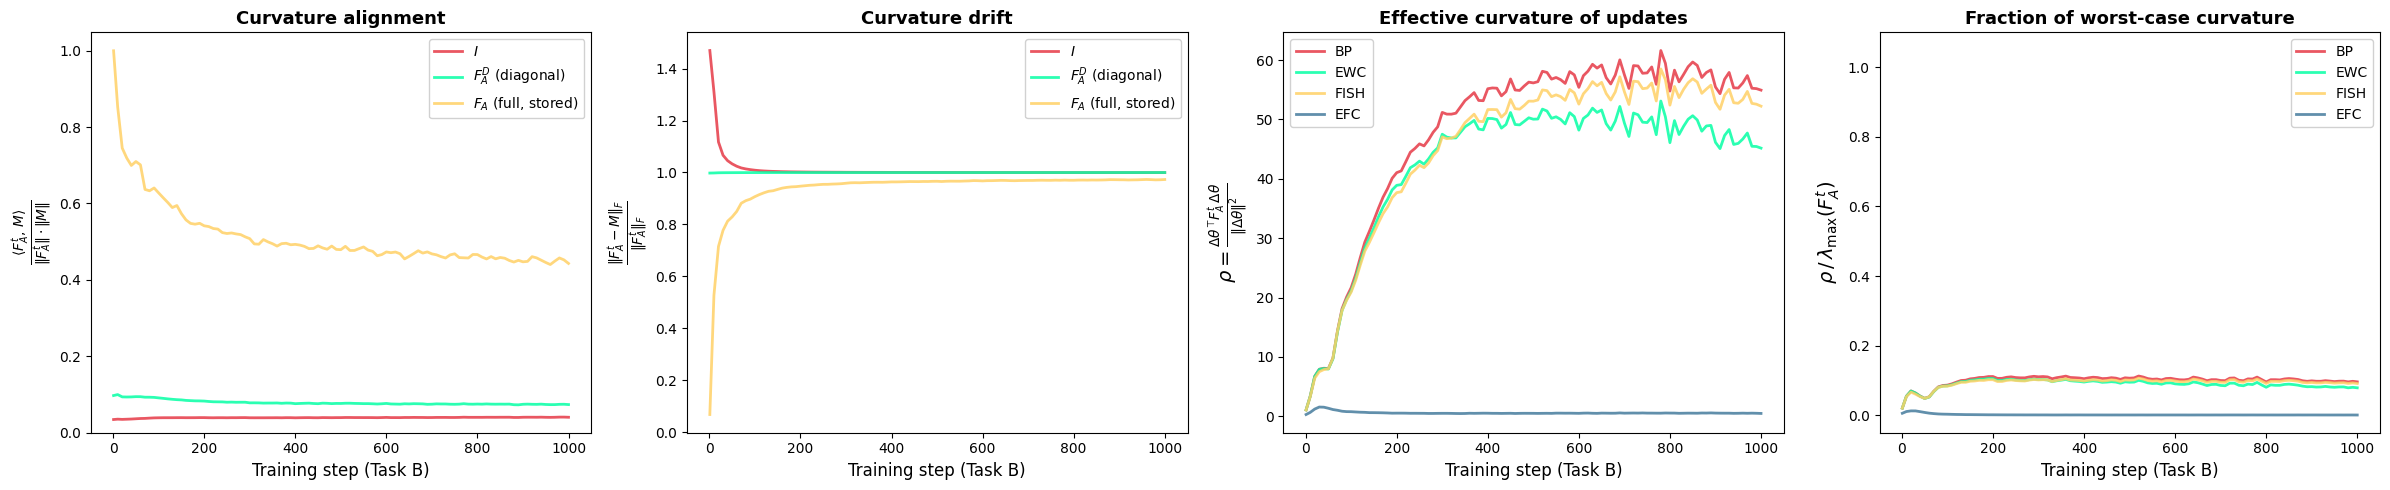

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(24, 5))

c_curvature = {'I': '#E63946', 'F_A^D': '#06FFA5', 'F_A': '#FFD166'}
c_method = {'BP': '#E63946', 'EWC': '#06FFA5', 'FISH': '#FFD166', 'EFC': '#457B9D'}
labels_12 = {'I': '$I$', 'F_A^D': r'$F_A^D$ (diagonal)', 'F_A': r'$F_A$ (full, stored)'}

steps = np.array(checkpoint_steps)

# ─── Plot 1: Curvature alignment ───
ax = axes[0]
for key in ['I', 'F_A^D', 'F_A']:
    ax.plot(steps, plot1_data[key], '-', color=c_curvature[key],
            label=labels_12[key], linewidth=2, markersize=4, alpha=0.85)
ax.set_xlabel('Training step (Task B)', fontsize=12)
ax.set_ylabel(r'$\frac{\langle F_A^t,\, M \rangle}{\| F_A^t \| \cdot \| M \|}$', fontsize=14)
ax.set_title('Curvature alignment', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, framealpha=0.9)
ax.set_ylim(bottom=0)

# ─── Plot 2: Curvature drift ───
ax = axes[1]
for key in ['I', 'F_A^D', 'F_A']:
    ax.plot(steps, plot2_data[key], '-', color=c_curvature[key],
            label=labels_12[key], linewidth=2, markersize=4, alpha=0.85)
ax.set_xlabel('Training step (Task B)', fontsize=12)
ax.set_ylabel(r'$\frac{\| F_A^t - M \|_F}{\| F_A^t \|_F}$', fontsize=14)
ax.set_title('Curvature drift', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, framealpha=0.9)

# ─── Plot 3: Effective curvature (raw) ───
ax = axes[2]
for key in ['BP', 'EWC', 'FISH', 'EFC']:
    ax.plot(steps, plot3_data[key], '-', color=c_method[key],
            label=key, linewidth=2, markersize=4, alpha=0.85)
ax.set_xlabel('Training step (Task B)', fontsize=12)
ax.set_ylabel(r'$\rho = \frac{\Delta\theta^\top F_A^t \, \Delta\theta}{\|\Delta\theta\|^2}$', fontsize=14)
ax.set_title('Effective curvature of updates', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, framealpha=0.9)

# ─── Plot 4: Normalized effective curvature ───
ax = axes[3]
for key in ['BP', 'EWC', 'FISH', 'EFC']:
    ax.plot(steps, plot4_data[key], '-', color=c_method[key],
            label=key, linewidth=2, markersize=4, alpha=0.85)
ax.set_xlabel('Training step (Task B)', fontsize=12)
ax.set_ylabel(r'$\rho \, / \, \lambda_{\max}(F_A^t)$', fontsize=14)
ax.set_title('Fraction of worst-case curvature', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, framealpha=0.9)
ax.set_ylim(-0.05, 1.1)

plt.tight_layout()
plt.savefig('figs/curvature_drift.svg', format='svg', bbox_inches='tight')
plt.savefig('figs/curvature_drift.pdf', format='pdf', bbox_inches='tight')
plt.savefig('figs/curvature_drift.eps', format='eps', bbox_inches='tight')
plt.show()

In [7]:
plot4_data["EFC"][50:55]

[0.0009652775671088386,
 0.000946891838585316,
 0.0009844554894897354,
 0.0009764192630588378,
 0.0009329986394905391]